<a href="https://colab.research.google.com/github/gar-nov/tirocinio/blob/main/DS_HIGH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

Mounted at /content/drive


In [ ]:
print(os.listdir("/content/drive/MyDrive/VEREMI_ATTACKS_HIGH"))

['veins_maat.uc1.14505241.180205_165658.tar', 'veins_maat.uc1.14505320.180205_170849.tar', 'veins_maat.uc1.14505498.180205_173315.tar', 'veins_maat.uc1.14505918.180205_192512.tar', 'veins_maat.uc1.14506010.180205_200124.tar']


In [ ]:
import tarfile
import json
import pandas as pd
import os

base_path = "/content/drive/MyDrive/VEREMI_ATTACKS_HIGH"

all_rows = []

for fname in os.listdir(base_path):
    if fname.endswith(".tar"):
        tar_path = os.path.join(base_path, fname)
        print("Estrazione:", fname)

        with tarfile.open(tar_path, "r") as tar:

            # 1) Leggo la Ground Truth
            gt_entries = []
            for member in tar.getmembers():
                if "GroundTruthJSONlog.json" in member.name:
                    f = tar.extractfile(member)
                    for line in f:
                        line = line.decode("utf-8").strip()
                        if line:
                            gt_entries.append(json.loads(line))
                    break

            # Mapping sender → attacker (0 benign, 1 attacker)
            label_map = {
                entry["sender"]: 1 if entry["attackerType"] > 0 else 0
                for entry in gt_entries
            }

            # 2) Leggo tutti i JSONlog
            for member in tar.getmembers():
                if "JSONlog-" in member.name:
                    f = tar.extractfile(member)
                    for line in f:
                        line = line.decode("utf-8").strip()
                        if not line:
                            continue

                        msg = json.loads(line)

                        # 🔥 Considero SOLO type == 3 (contiene sender)
                        if msg.get("type") != 3:
                            continue

                        sender = msg["sender"]
                        msg["attack"] = label_map.get(sender, 0)
                        msg["source_file"] = fname
                        all_rows.append(msg)

df = pd.DataFrame(all_rows)
print("Shape finale:", df.shape)
df.head()

Estrazione: veins_maat.uc1.14505241.180205_165658.tar
Estrazione: veins_maat.uc1.14505320.180205_170849.tar
Estrazione: veins_maat.uc1.14505498.180205_173315.tar
Estrazione: veins_maat.uc1.14505918.180205_192512.tar
Estrazione: veins_maat.uc1.14506010.180205_200124.tar
Shape finale: (2506250, 12)


,type,rcvTime,sendTime,sender,messageID,pos,pos_noise,spd,spd_noise,RSSI,attack,source_file
0,3,25286.120024,25286.119913,1807,5632683,"[2742.7138937767895, 5472.925796457284, 1.895]","[0.0, 0.0, 0.0]","[0.0, -0.0, 0.0]","[0.0, 0.0, 0.0]",2.408328e-08,0,veins_maat.uc1.14505241.180205_165658.tar
1,3,25286.383047,25286.382929,2107,5648256,"[5560.0, 5820.0, 1.895]","[0.0, 0.0, 0.0]","[0.0, -0.0, 0.0]","[0.0, 0.0, 0.0]",2.331271e-08,1,veins_maat.uc1.14505241.180205_165658.tar
2,3,25286.437927,25286.437814,721,5653675,"[2754.0700849399805, 5459.842522534191, 1.895]","[0.0, 0.0, 0.0]","[-0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",4.196330e-08,0,veins_maat.uc1.14505241.180205_165658.tar
3,3,25286.588929,25286.588812,781,5660913,"[2754.8523725690366, 5463.0423461191, 1.895]","[0.0, 0.0, 0.0]","[-0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",4.063461e-08,0,veins_maat.uc1.14505241.180205_165658.tar
4,3,25286.655795,25286.655677,1789,5665095,"[2743.5948766953566, 5476.105587331986, 1.895]","[0.0, 0.0, 0.0]","[0.0, -0.0, 0.0]","[0.0, 0.0, 0.0]",3.952188e-08,0,veins_maat.uc1.14505241.180205_165658.tar


In [ ]:
df.shape

(2506250, 12)

In [ ]:
# Controllo distribuzione
df["attack"].value_counts()

,count
attack,
0,2025087
1,481163


In [ ]:
# --- Estraggo pos x,y,z ---
df["pos_x"] = df["pos"].apply(lambda v: v[0])
df["pos_y"] = df["pos"].apply(lambda v: v[1])
df["pos_z"] = df["pos"].apply(lambda v: v[2])

# --- Estraggo pos_noise x,y,z ---
df["pos_noise_x"] = df["pos_noise"].apply(lambda v: v[0])
df["pos_noise_y"] = df["pos_noise"].apply(lambda v: v[1])
df["pos_noise_z"] = df["pos_noise"].apply(lambda v: v[2])

# --- Estraggo speed x,y,z ---
df["spd_x"] = df["spd"].apply(lambda v: v[0])
df["spd_y"] = df["spd"].apply(lambda v: v[1])
df["spd_z"] = df["spd"].apply(lambda v: v[2])

# --- Estraggo speed_noise x,y,z ---
df["spd_noise_x"] = df["spd_noise"].apply(lambda v: v[0])
df["spd_noise_y"] = df["spd_noise"].apply(lambda v: v[1])
df["spd_noise_z"] = df["spd_noise"].apply(lambda v: v[2])

# Mostra il dataframe completo con TUTTE le colonne
df.head()

,type,rcvTime,sendTime,sender,messageID,pos,pos_noise,spd,spd_noise,RSSI,...,pos_z,pos_noise_x,pos_noise_y,pos_noise_z,spd_x,spd_y,spd_z,spd_noise_x,spd_noise_y,spd_noise_z
0,3,25286.120024,25286.119913,1807,5632683,"[2742.7138937767895, 5472.925796457284, 1.895]","[0.0, 0.0, 0.0]","[0.0, -0.0, 0.0]","[0.0, 0.0, 0.0]",2.408328e-08,...,1.895,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0
1,3,25286.383047,25286.382929,2107,5648256,"[5560.0, 5820.0, 1.895]","[0.0, 0.0, 0.0]","[0.0, -0.0, 0.0]","[0.0, 0.0, 0.0]",2.331271e-08,...,1.895,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0
2,3,25286.437927,25286.437814,721,5653675,"[2754.0700849399805, 5459.842522534191, 1.895]","[0.0, 0.0, 0.0]","[-0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",4.196330e-08,...,1.895,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0
3,3,25286.588929,25286.588812,781,5660913,"[2754.8523725690366, 5463.0423461191, 1.895]","[0.0, 0.0, 0.0]","[-0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",4.063461e-08,...,1.895,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0
4,3,25286.655795,25286.655677,1789,5665095,"[2743.5948766953566, 5476.105587331986, 1.895]","[0.0, 0.0, 0.0]","[0.0, -0.0, 0.0]","[0.0, 0.0, 0.0]",3.952188e-08,...,1.895,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0


In [ ]:
# --- Cancello le colonne originali ---
df = df.drop(columns=["source_file"])

# Mostro il dataframe completo pulito
df.head()

,type,rcvTime,sendTime,sender,messageID,RSSI,attack,pos_x,pos_y,pos_z,pos_noise_x,pos_noise_y,pos_noise_z,spd_x,spd_y,spd_z,spd_noise_x,spd_noise_y,spd_noise_z
0,3,25286.120024,25286.119913,1807,5632683,2.408328e-08,0,2742.713894,5472.925796,1.895,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0
1,3,25286.383047,25286.382929,2107,5648256,2.331271e-08,1,5560.000000,5820.000000,1.895,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0
2,3,25286.437927,25286.437814,721,5653675,4.196330e-08,0,2754.070085,5459.842523,1.895,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0
3,3,25286.588929,25286.588812,781,5660913,4.063461e-08,0,2754.852373,5463.042346,1.895,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0
4,3,25286.655795,25286.655677,1789,5665095,3.952188e-08,0,2743.594877,5476.105587,1.895,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0


In [ ]:
df.duplicated().sum()

np.int64(413540)

In [ ]:
df_clean = df.drop_duplicates()

In [ ]:
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
df_clean.shape

(2092710, 19)

In [ ]:
# Controllo distribuzione
df_clean["attack"].value_counts()

,count
attack,
0,1611547
1,481163


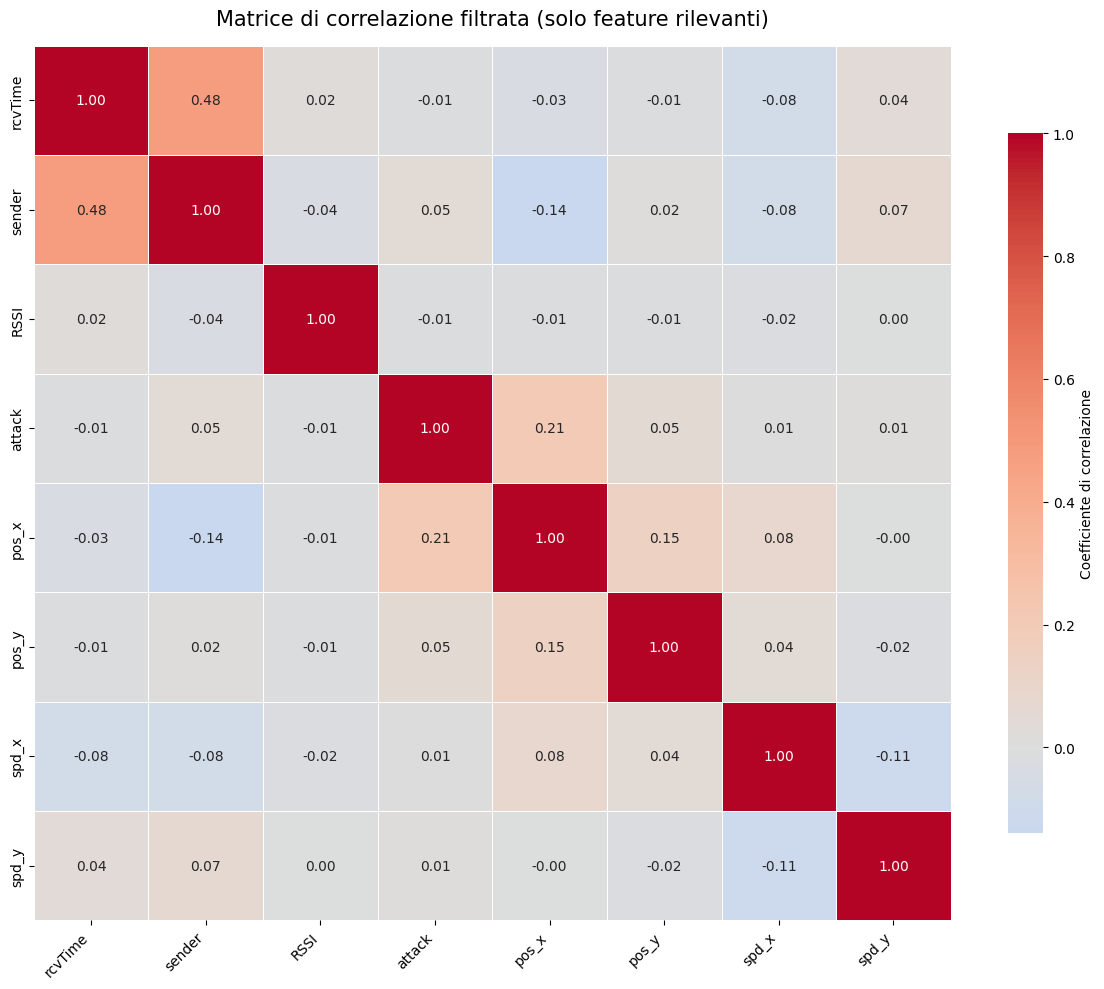

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
cols_to_drop = [
    "type",
    "pos_z",
    "spd_z",
    "pos_noise_x", "pos_noise_y", "pos_noise_z",
    "spd_noise_x", "spd_noise_y", "spd_noise_z",
    "sendTime",
    "messageID"
]

df_corr = df_clean.drop(columns=cols_to_drop)

# Calcolo matrice di correlazione solo sulle feature utili
df_num = df_corr.select_dtypes(include=['float64', 'int64'])
corr_matrix = df_num.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10},
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Coefficiente di correlazione"}
)

plt.title("Matrice di correlazione filtrata (solo feature rilevanti)", fontsize=15, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

/tmp/ipython-input-1745337066.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-1745337066.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-1745337066.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-1745337066.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-1745337066.py:15: FutureWarning: 

Passin

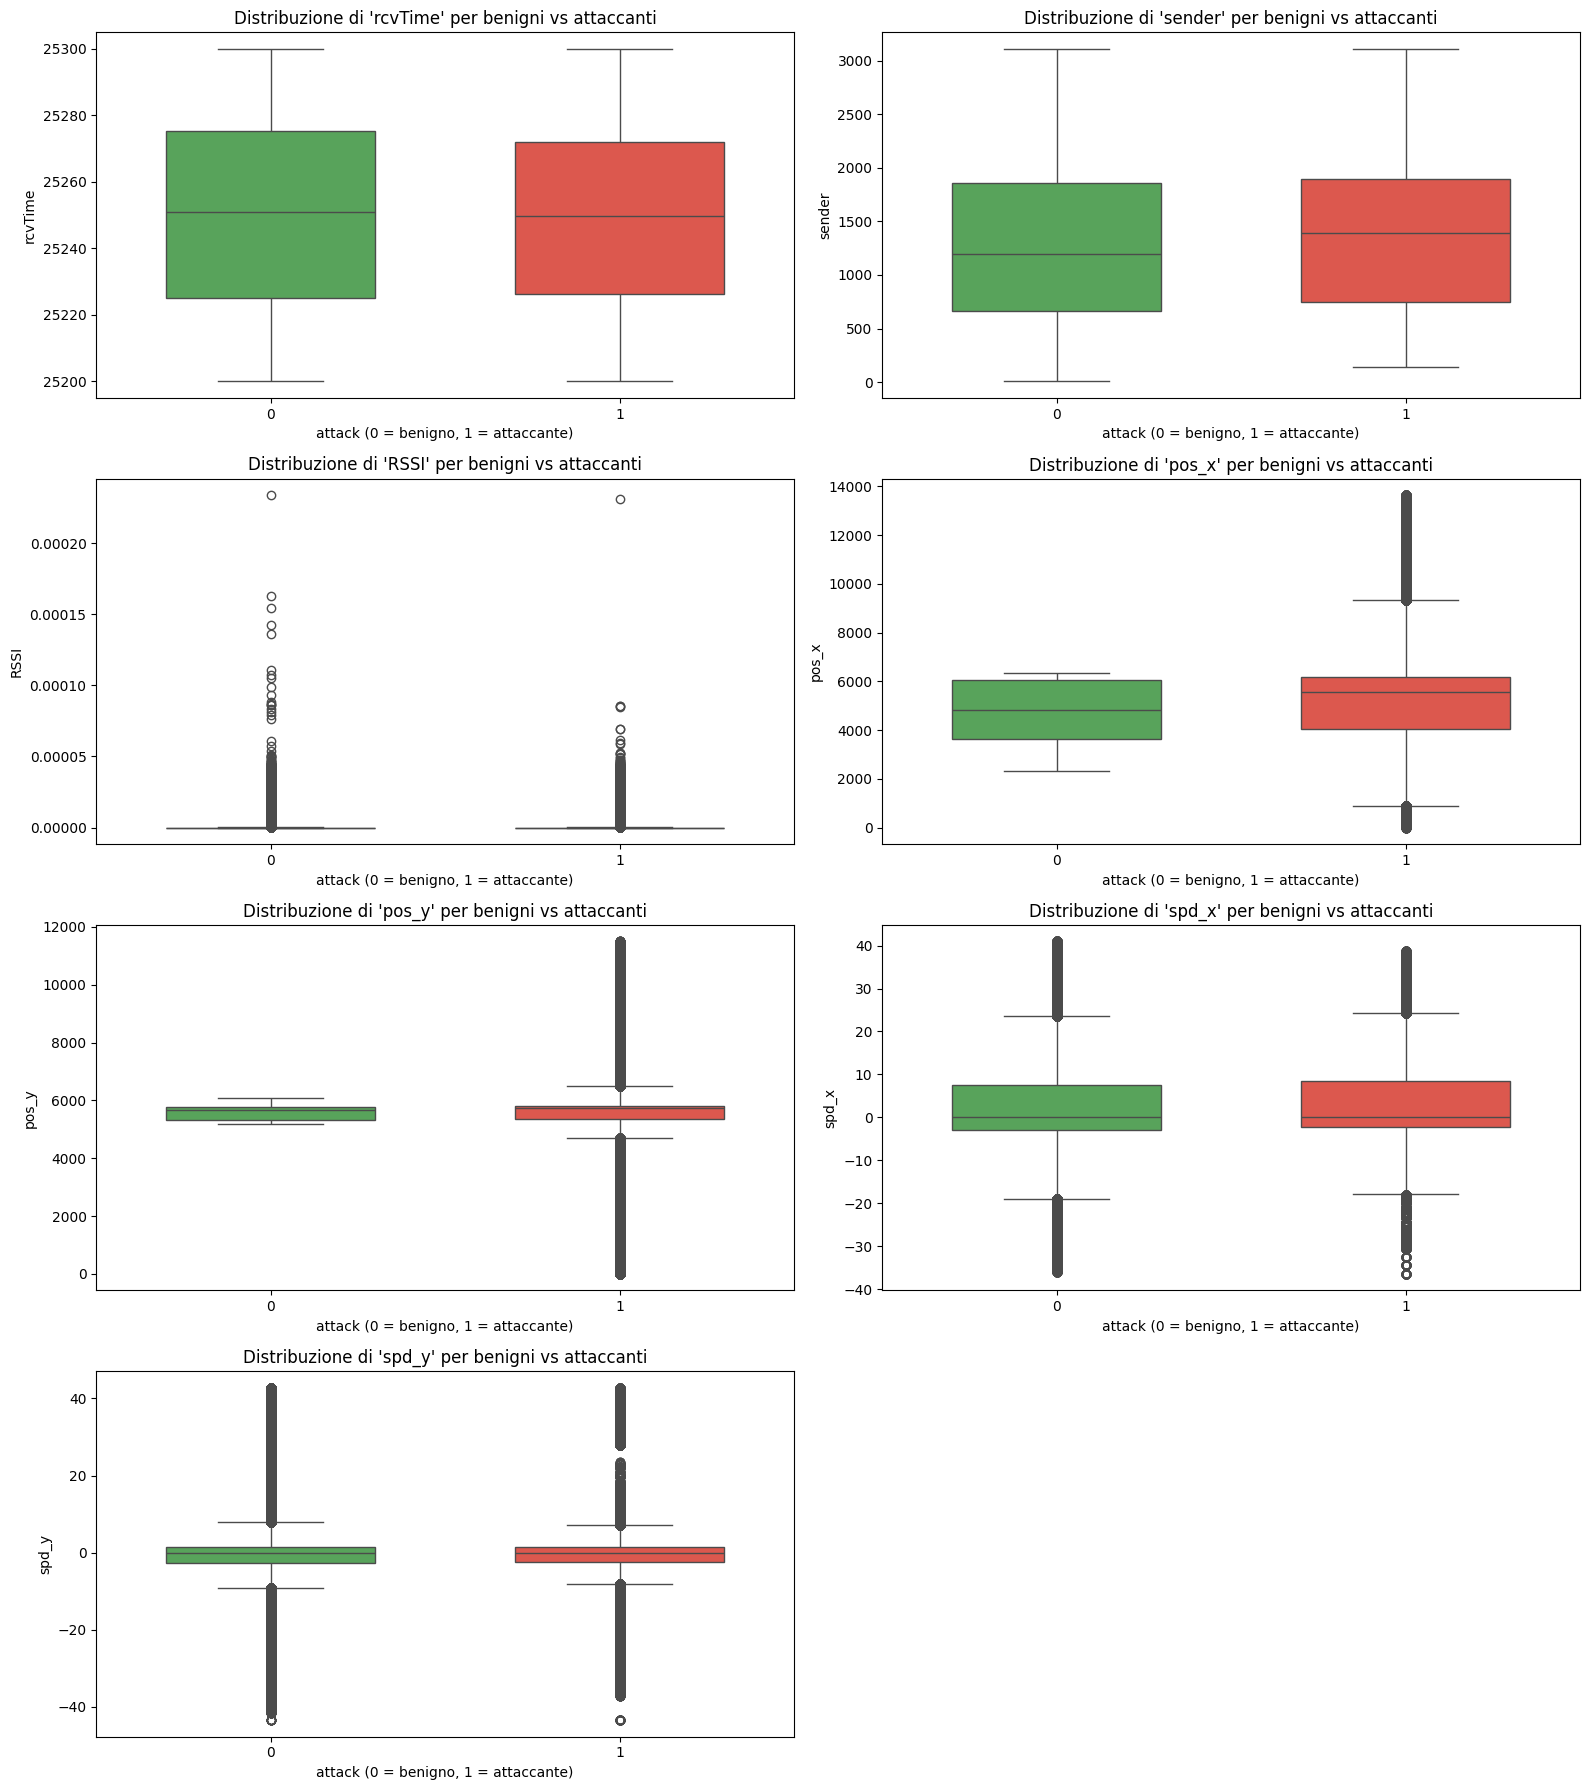

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleziono solo le feature numeriche (escluse label e colonne inutili)
cols_for_boxplot = [
    "rcvTime", "sender", "RSSI",
    "pos_x", "pos_y",
    "spd_x", "spd_y"
]

plt.figure(figsize=(16, 18))

for i, col in enumerate(cols_for_boxplot, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(
        data=df_clean,
        x="attack",
        y=col,
        palette=["#4CAF50", "#F44336"],   # verde vs rosso (benigno vs attacco)
        width=0.6
    )
    plt.title(f"Distribuzione di '{col}' per benigni vs attaccanti", fontsize=12)
    plt.xlabel("attack (0 = benigno, 1 = attaccante)")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [38]:
df_clean.shape

(2092710, 19)

In [39]:
from sklearn.model_selection import train_test_split

# Numero totale di righe del dataset medium density (density 5)
target_size = 81836

# Fraczione da estrarre dal dataset high density (density 7)
fraction = target_size / len(df_clean)

# Campionamento stratificato del dataset ad alta densità
df7_sampled, _ = train_test_split(
    df_clean,
    test_size = 1 - fraction,
    stratify = df_clean['attack'],
    random_state = 42
)

print(df7_sampled.shape)
print(df7_sampled['attack'].value_counts(normalize=True))




(81836, 19)
attack
0    0.770077
1    0.229923
Name: proportion, dtype: float64


In [40]:
import pandas as pd

top_features = ['pos_x', 'pos_y', 'spd_x', 'spd_y', 'sender', 'messageID','sendTime']

X = df7_sampled[top_features]
y = df7_sampled['attack']



In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)": SVC(kernel='rbf'),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}

results = []

for name, model in models.items():
    # SVM, KNN e LR richiedono scaling
    if name in ["Logistic Regression", "KNN", "SVM (RBF)"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

df_results = pd.DataFrame(results, columns=["Modello", "Accuracy", "Precisione", "Recall", "F1-score"])
print(df_results)

               Modello  Accuracy  Precisione    Recall  F1-score
0  Logistic Regression  0.786901    1.000000  0.073080  0.136206
1                  KNN  0.958639    0.976529  0.840287  0.903300
2            SVM (RBF)  0.836510    0.990967  0.291523  0.450513
3        Random Forest  0.995479    0.998379  0.981929  0.990086
4        Decision Tree  0.993035    0.991117  0.978475  0.984755
5          Naive Bayes  0.816166    1.000000  0.200372  0.333850


In [44]:
# Copia la tabella e arrotonda i valori
df_results_nice = df_results.copy()
df_results_nice[["Accuracy", "Precisione", "Recall", "F1-score"]] = \
    df_results_nice[["Accuracy", "Precisione", "Recall", "F1-score"]].round(4)

# Tabella con stile (sfondo header blu, testo bianco)
df_results_nice.style.set_properties(**{
    "background-color": "white",
    "color": "black",
    "border-color": "black",
    "border-width": "1px",
    "border-style": "solid",
    "text-align": "center"
}).set_table_styles([
    {"selector": "th", "props": [
        ("background-color", "#1F4E79"),
        ("color", "white"),
        ("font-weight", "bold"),
        ("text-align", "center")
    ]},
    {"selector": "td", "props": [
        ("padding", "8px")
    ]}
])

,Modello,Accuracy,Precisione,Recall,F1-score
0,Logistic Regression,0.786900,1.000000,0.073100,0.136200
1,KNN,0.958600,0.976500,0.840300,0.903300
2,SVM (RBF),0.836500,0.991000,0.291500,0.450500
3,Random Forest,0.995500,0.998400,0.981900,0.990100
4,Decision Tree,0.993000,0.991100,0.978500,0.984800
5,Naive Bayes,0.816200,1.000000,0.200400,0.333800
